# Fast Agent - Build a SQL Agent fast!

## Setup
Load and/or check for needed environmental variables

In [58]:
from dotenv import load_dotenv

load_dotenv()

True

In [59]:
from pathlib import Path
from langchain_community.utilities import SQLDatabase

db_path = Path.cwd() / "Chinook.db"

db = SQLDatabase.from_uri(f"sqlite:///{db_path}")

In [60]:
import os

print(os.path.exists("Chinook.db"))

True


Define the runtime context to provide the agent and tools with access to the database.

In [61]:
from dataclasses import dataclass

from langchain_community.utilities import SQLDatabase

@dataclass
class RuntimeContext:
    db: SQLDatabase

⚠️ Security Note: This demo does not include a filter on LLM-generated commands. In production, you would want to limit the scope of LLM-generated commands. ⚠️
This tool will connect to the database. Note the use of get_runtime to access the graph runtime context.

In [62]:
from langchain_core.tools import tool
from langgraph.runtime import get_runtime

@tool
def execute_sql(query: str) -> str:
    """Execute a SQLite command and return results."""
    runtime = get_runtime(RuntimeContext)
    db = runtime.context.db

    try:
        return db.run(query) # type: ignore
    except Exception as e:
        return f"Error: {e}"

Add a system prompt to define your agents behavior.

In [63]:
SYSTEM_PROMPT = """You are a careful SQLite analyst.

Rules:
- Think step-by-step.
- When you need data, call the tool `execute_sql` with ONE SELECT query.
- Read-only only; no INSERT/UPDATE/DELETE/ALTER/DROP/CREATE/REPLACE/TRUNCATE.
- Limit to 5 rows of output unless the user explicitly asks otherwise.
- If the tool returns 'Error:', revise the SQL and try again.
- Prefer explicit column lists; avoid SELECT *.
"""

Create your agent! Add a model, tools, a prompt, and the runtime access, and go! You can choose many agents from our integrations list.

In [64]:
from langchain_ollama import ChatOllama
from langchain.agents import create_agent

llm = ChatOllama(
    model="qwen2.5:3b",
    temperature=0,
)

agent = create_agent(
    model=llm,
    tools=[execute_sql],
    system_prompt=SYSTEM_PROMPT,
    context_schema=RuntimeContext,
)

Here's a display of the agent ReAct Loop.

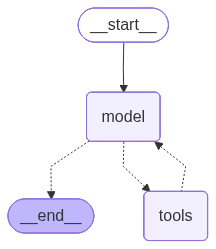

In [65]:
from IPython.display import Image, display

display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

Run some queries. Notice:

The agent does not have the database schema and will need to discover it independently.
The agent may make mistakes! By returning error messages, the agent can self-correct its queries.
Notice you invoke the agent with agent.stream.
This command and the pretty_print display the messages that communicate information between the model and the tools.
Notice the agent doesn't remember the schema between invocations... More on this later!

In [66]:
question = "Which table has the largest number of entries?"

for step in agent.stream(
    {"messages": question},
    context=RuntimeContext(db=db),
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Which table has the largest number of entries?
================================== Ai Message ==================================

To find which table has the largest number of entries, we need to execute a query that counts the rows in each table. Let's start by executing such a query.
Tool Calls:
  execute_sql (aed10d3b-3d4a-4598-9e88-e20b2e074117)
 Call ID: aed10d3b-3d4a-4598-9e88-e20b2e074117
  Args:
    query: SELECT name, COUNT(*) as row_count FROM sqlite_master GROUP BY name ORDER BY row_count DESC LIMIT 1;
================================= Tool Message =================================
Name: execute_sql

[('sqlite_autoindex_PlaylistTrack_1', 1)]
================================== Ai Message ==================================

The execution returned results for one table: 'sqlite_autoindex_PlaylistTrack_1'. It seems there might be an error as we expected to get the count of rows in each table. Let's 

In [67]:
question = "Which genre on average has the longest tracks?"

for step in agent.stream(
    {"messages": question},
    context=RuntimeContext(db=db),
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Which genre on average has the longest tracks?
================================== Ai Message ==================================

To find out which genre has the longest tracks on average, we first need to calculate the average track length for each genre. Let's execute a query to get this information.
Tool Calls:
  execute_sql (6bbff1eb-fce8-46fe-b510-645fdd5f3e26)
 Call ID: 6bbff1eb-fce8-46fe-b510-645fdd5f3e26
  Args:
    query: SELECT genre, AVG(track_length) as avg_track_length FROM tracks GROUP BY genre ORDER BY avg_track_length DESC LIMIT 5;
================================= Tool Message =================================
Name: execute_sql

Error: (sqlite3.OperationalError) no such table: tracks
[SQL: SELECT genre, AVG(track_length) as avg_track_length FROM tracks GROUP BY genre ORDER BY avg_track_length DESC LIMIT 5;]
(Background on this error at: https://sqlalche.me/e/20/e3q8)
======================

In [68]:
question = "Please list all of the tables"

for step in agent.stream(
    {"messages": question},
    context={"db": db},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Please list all of the tables
================================== Ai Message ==================================
Tool Calls:
  execute_sql (065c1c64-fda7-4d84-8ca9-f3f8b258615b)
 Call ID: 065c1c64-fda7-4d84-8ca9-f3f8b258615b
  Args:
    query: SELECT name FROM sqlite_master WHERE type='table' ORDER BY name
================================= Tool Message =================================
Name: execute_sql

[('Album',), ('Artist',), ('Customer',), ('Employee',), ('Genre',), ('Invoice',), ('InvoiceLine',), ('MediaType',), ('Playlist',), ('PlaylistTrack',), ('Track',)]
================================== Ai Message ==================================

The tables available in the SQLite database are as follows:

- Album
- Artist
- Customer
- Employee
- Genre
- Invoice
- InvoiceLine
- MediaType
- Playlist
- PlaylistTrack
- Track

There are 10 tables listed. Is there anything specific you would like to know about the

Create your own query here! Add some questions of your own.